In [1]:
# ============================================================
# SANAE Summer Underway Data
# Scatter plots of:
#   - Salinity vs Years
#   - Temperature vs Years
#   - Total Alkalinity vs Years
#   - Total Carbon vs Years
#
# Data are filtered for:
#   - Summer only (Dec–Feb windows)
#   - Southern Ocean biomes
#
# Author: Sandile Dlaba
# ============================================================

# -----------------------------
# Import libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# -----------------------------
# Plot style
# -----------------------------
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

In [3]:
# -----------------------------
# File path
# -----------------------------
file_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Combined_Underway_clean.xlsx"

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_excel(file_path)

In [4]:
# -----------------------------
# Convert date column
# -----------------------------

df['Date'] = pd.to_datetime(df['Date'])

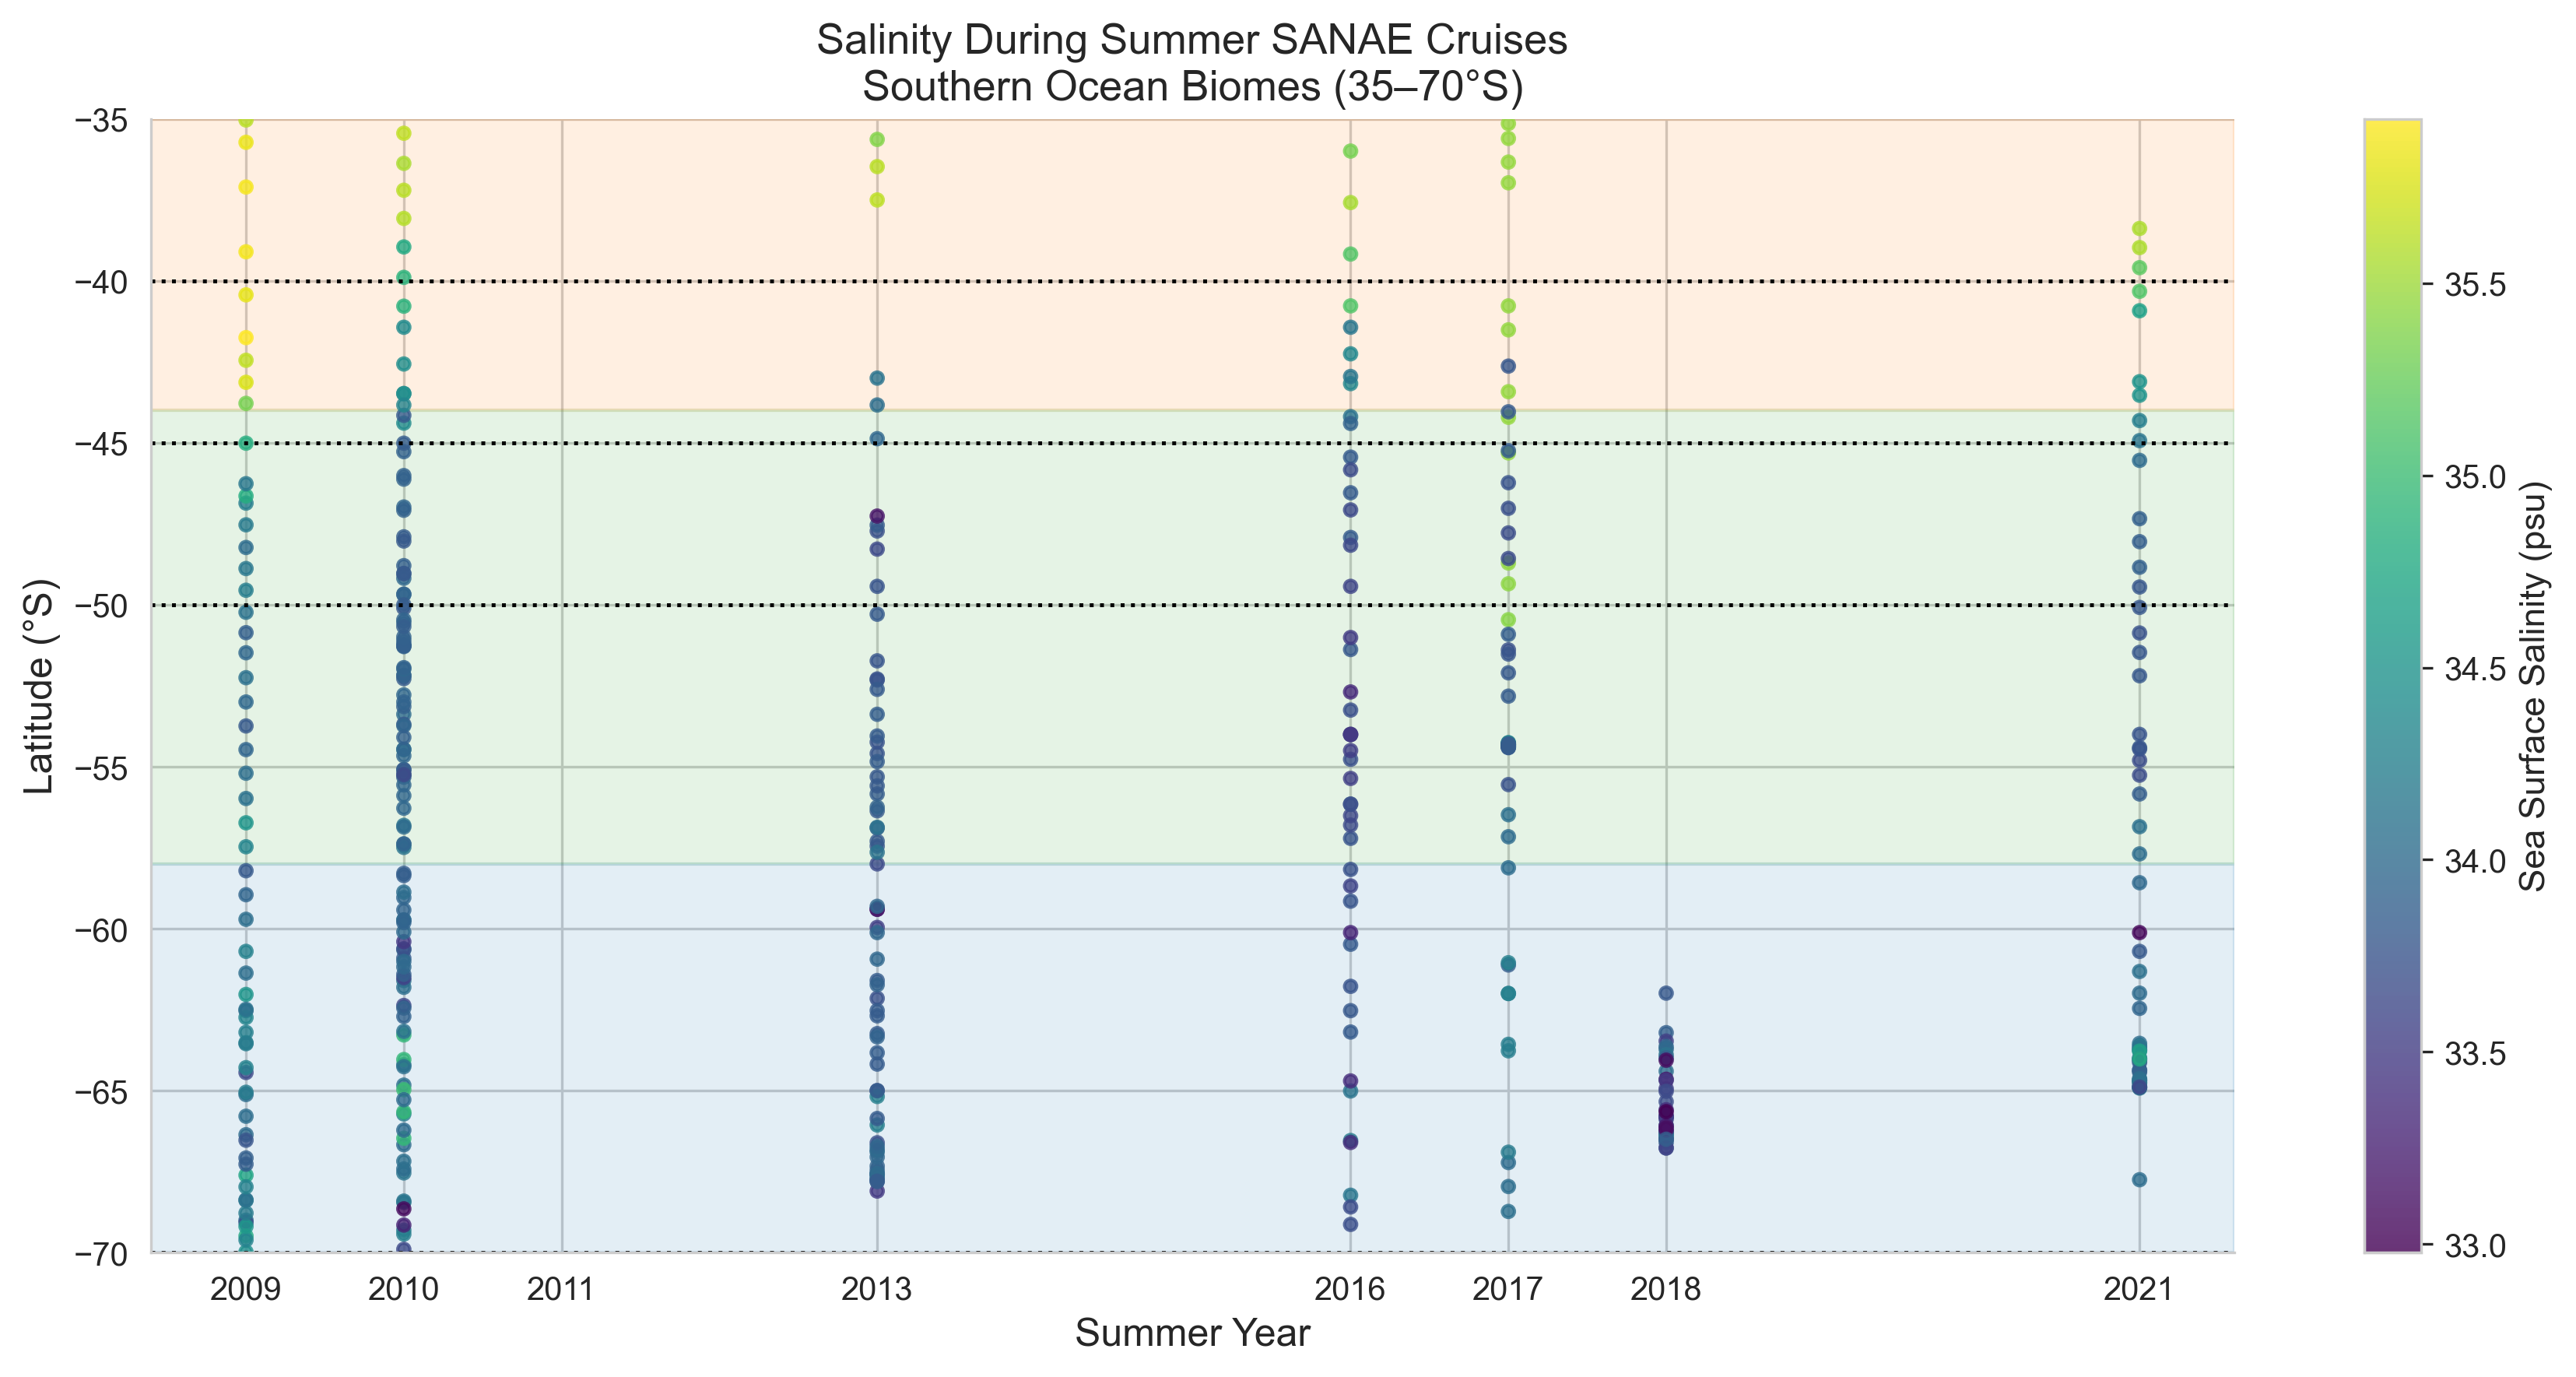

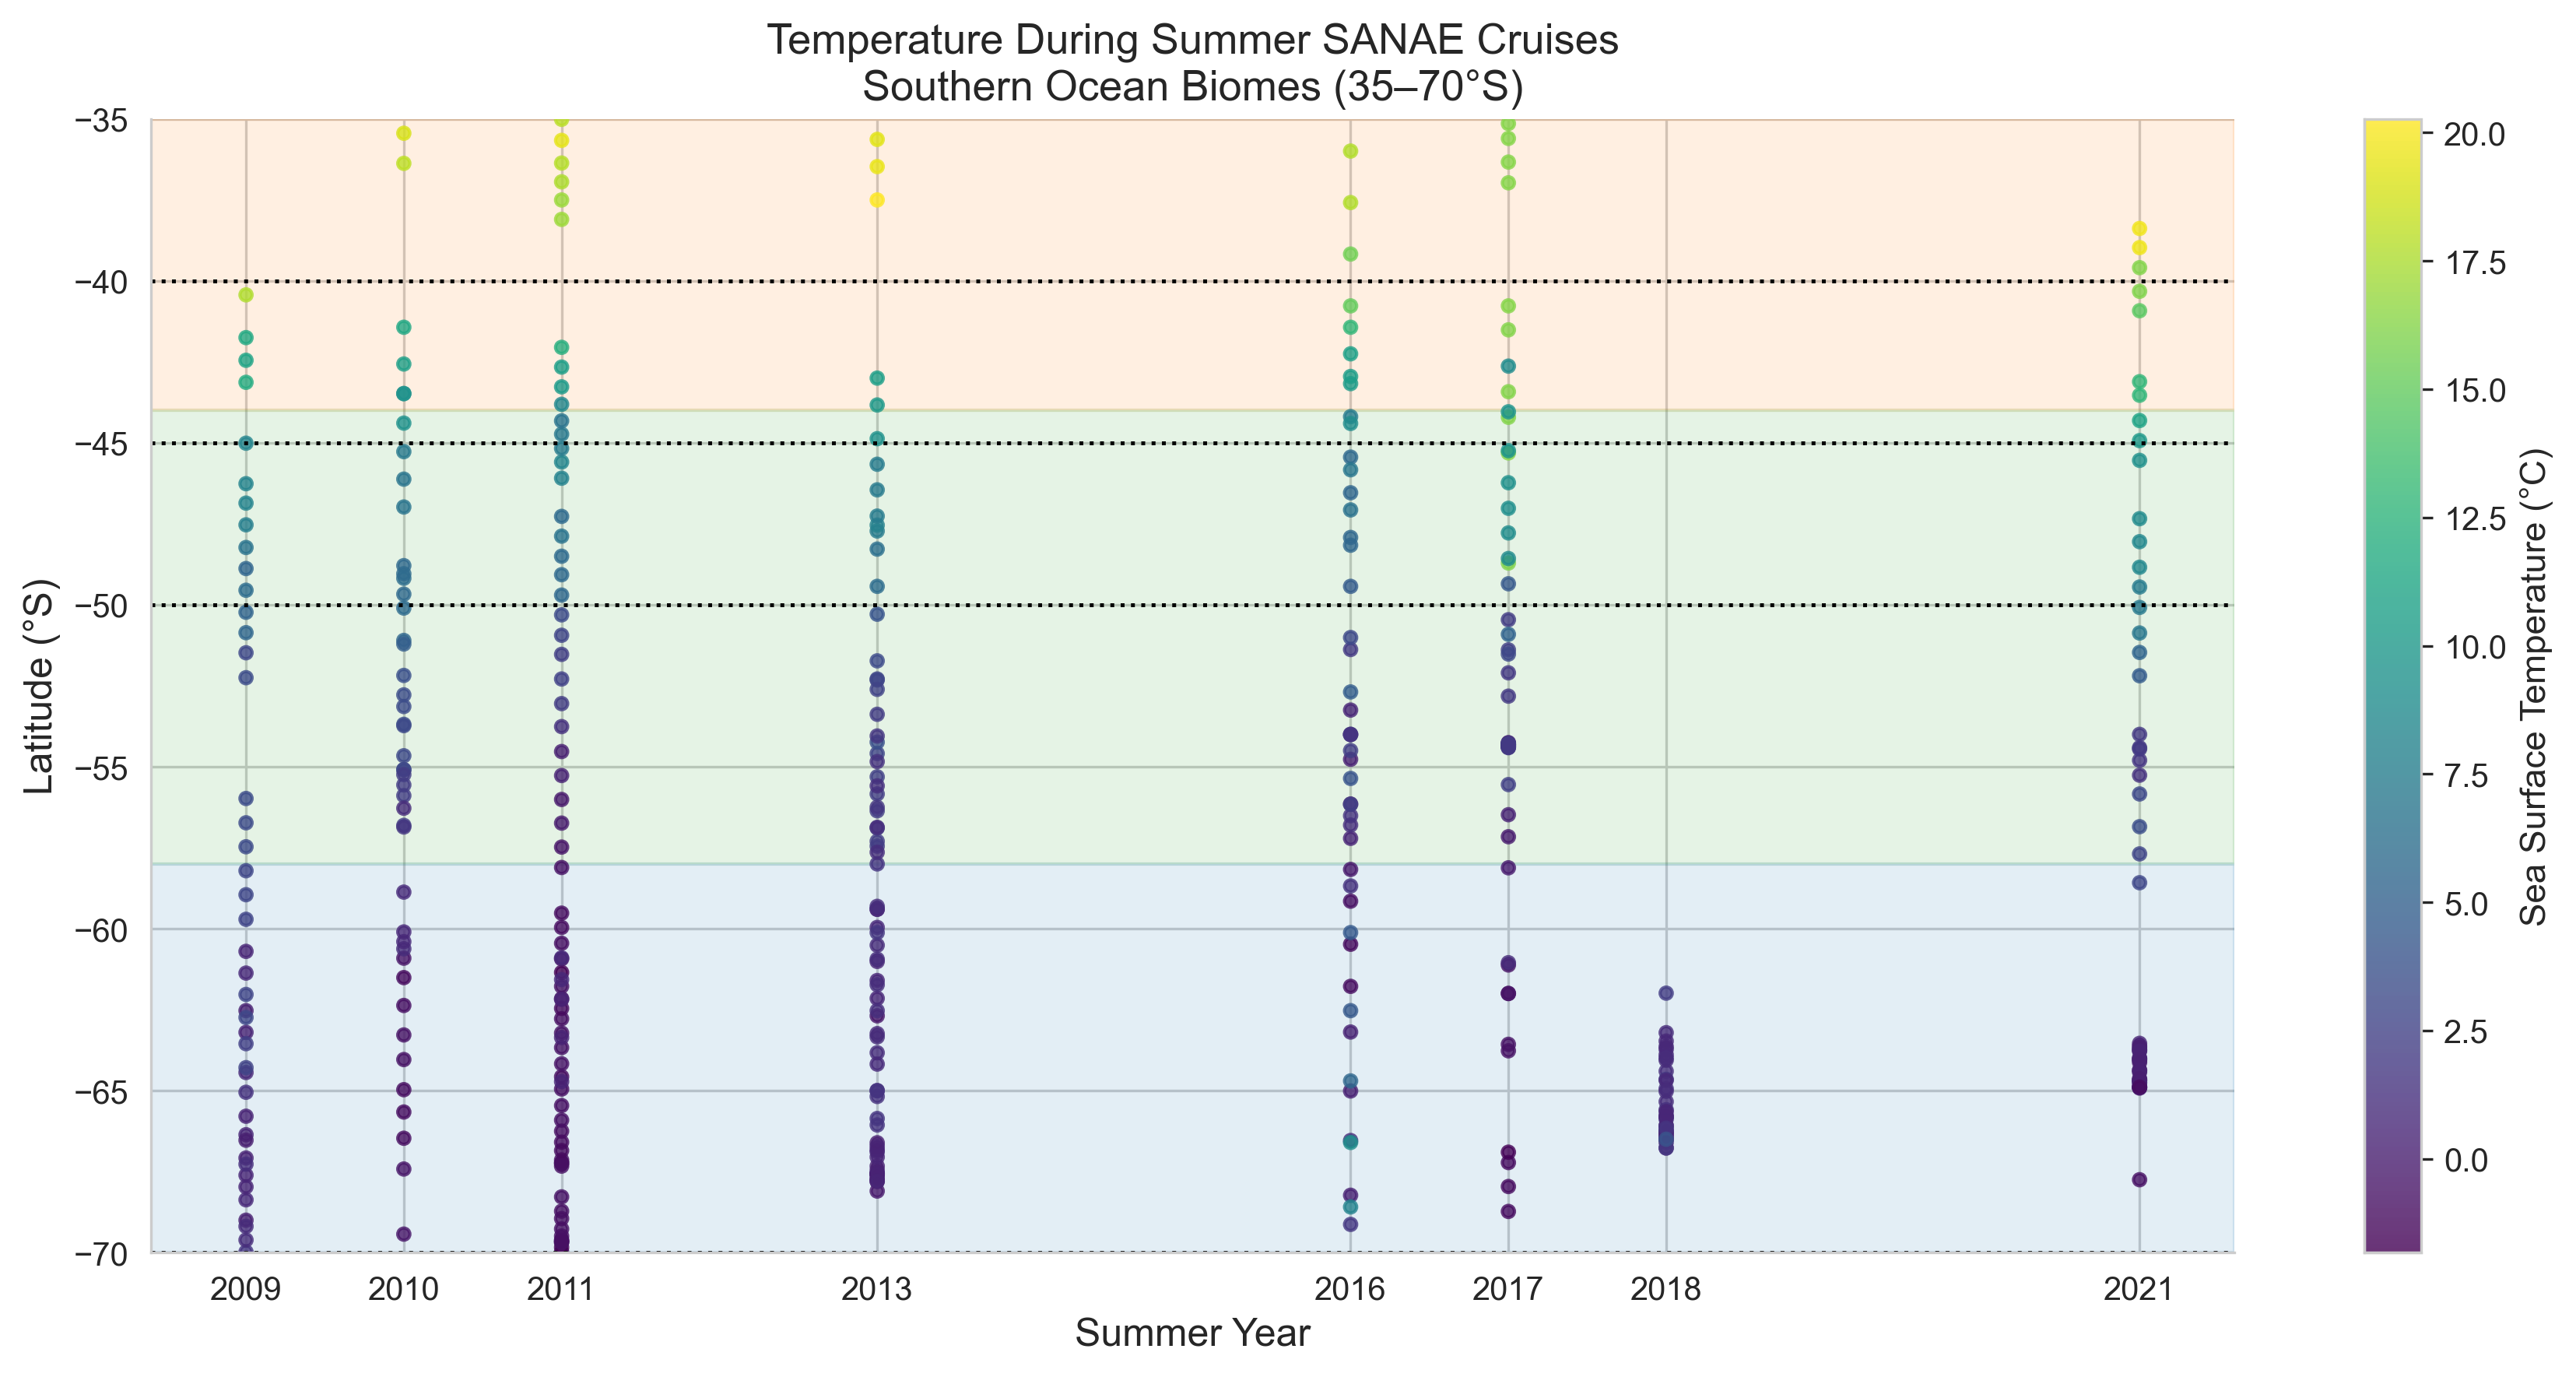

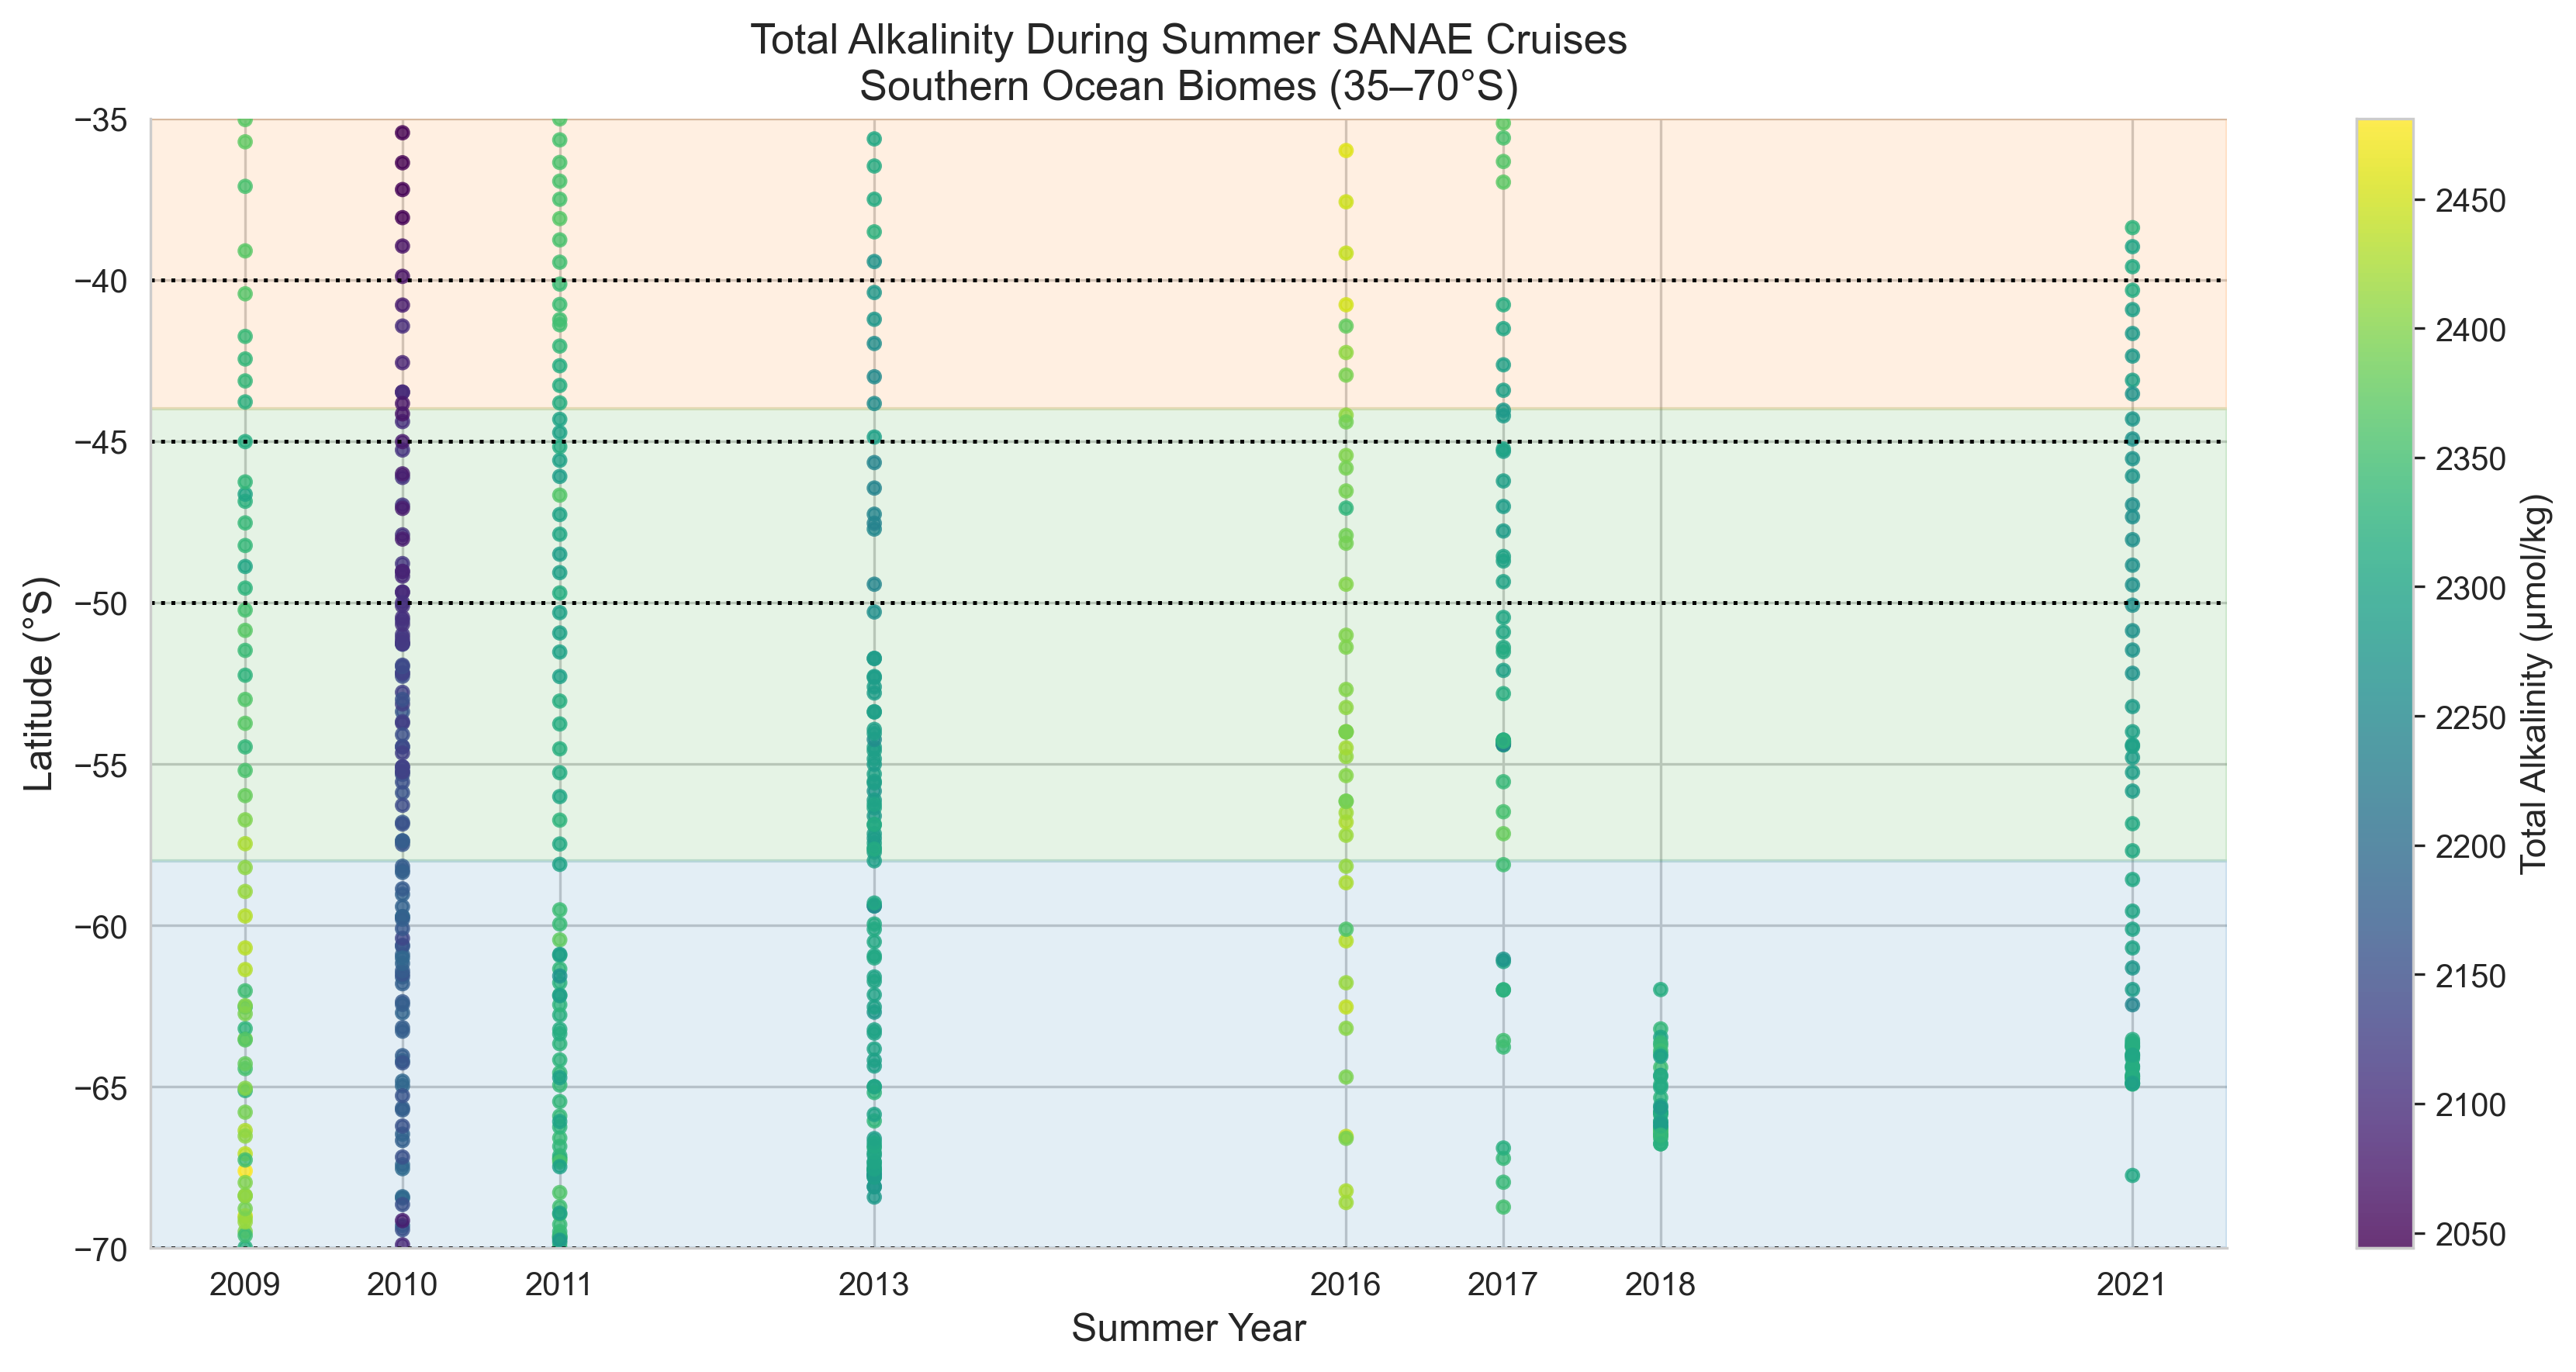

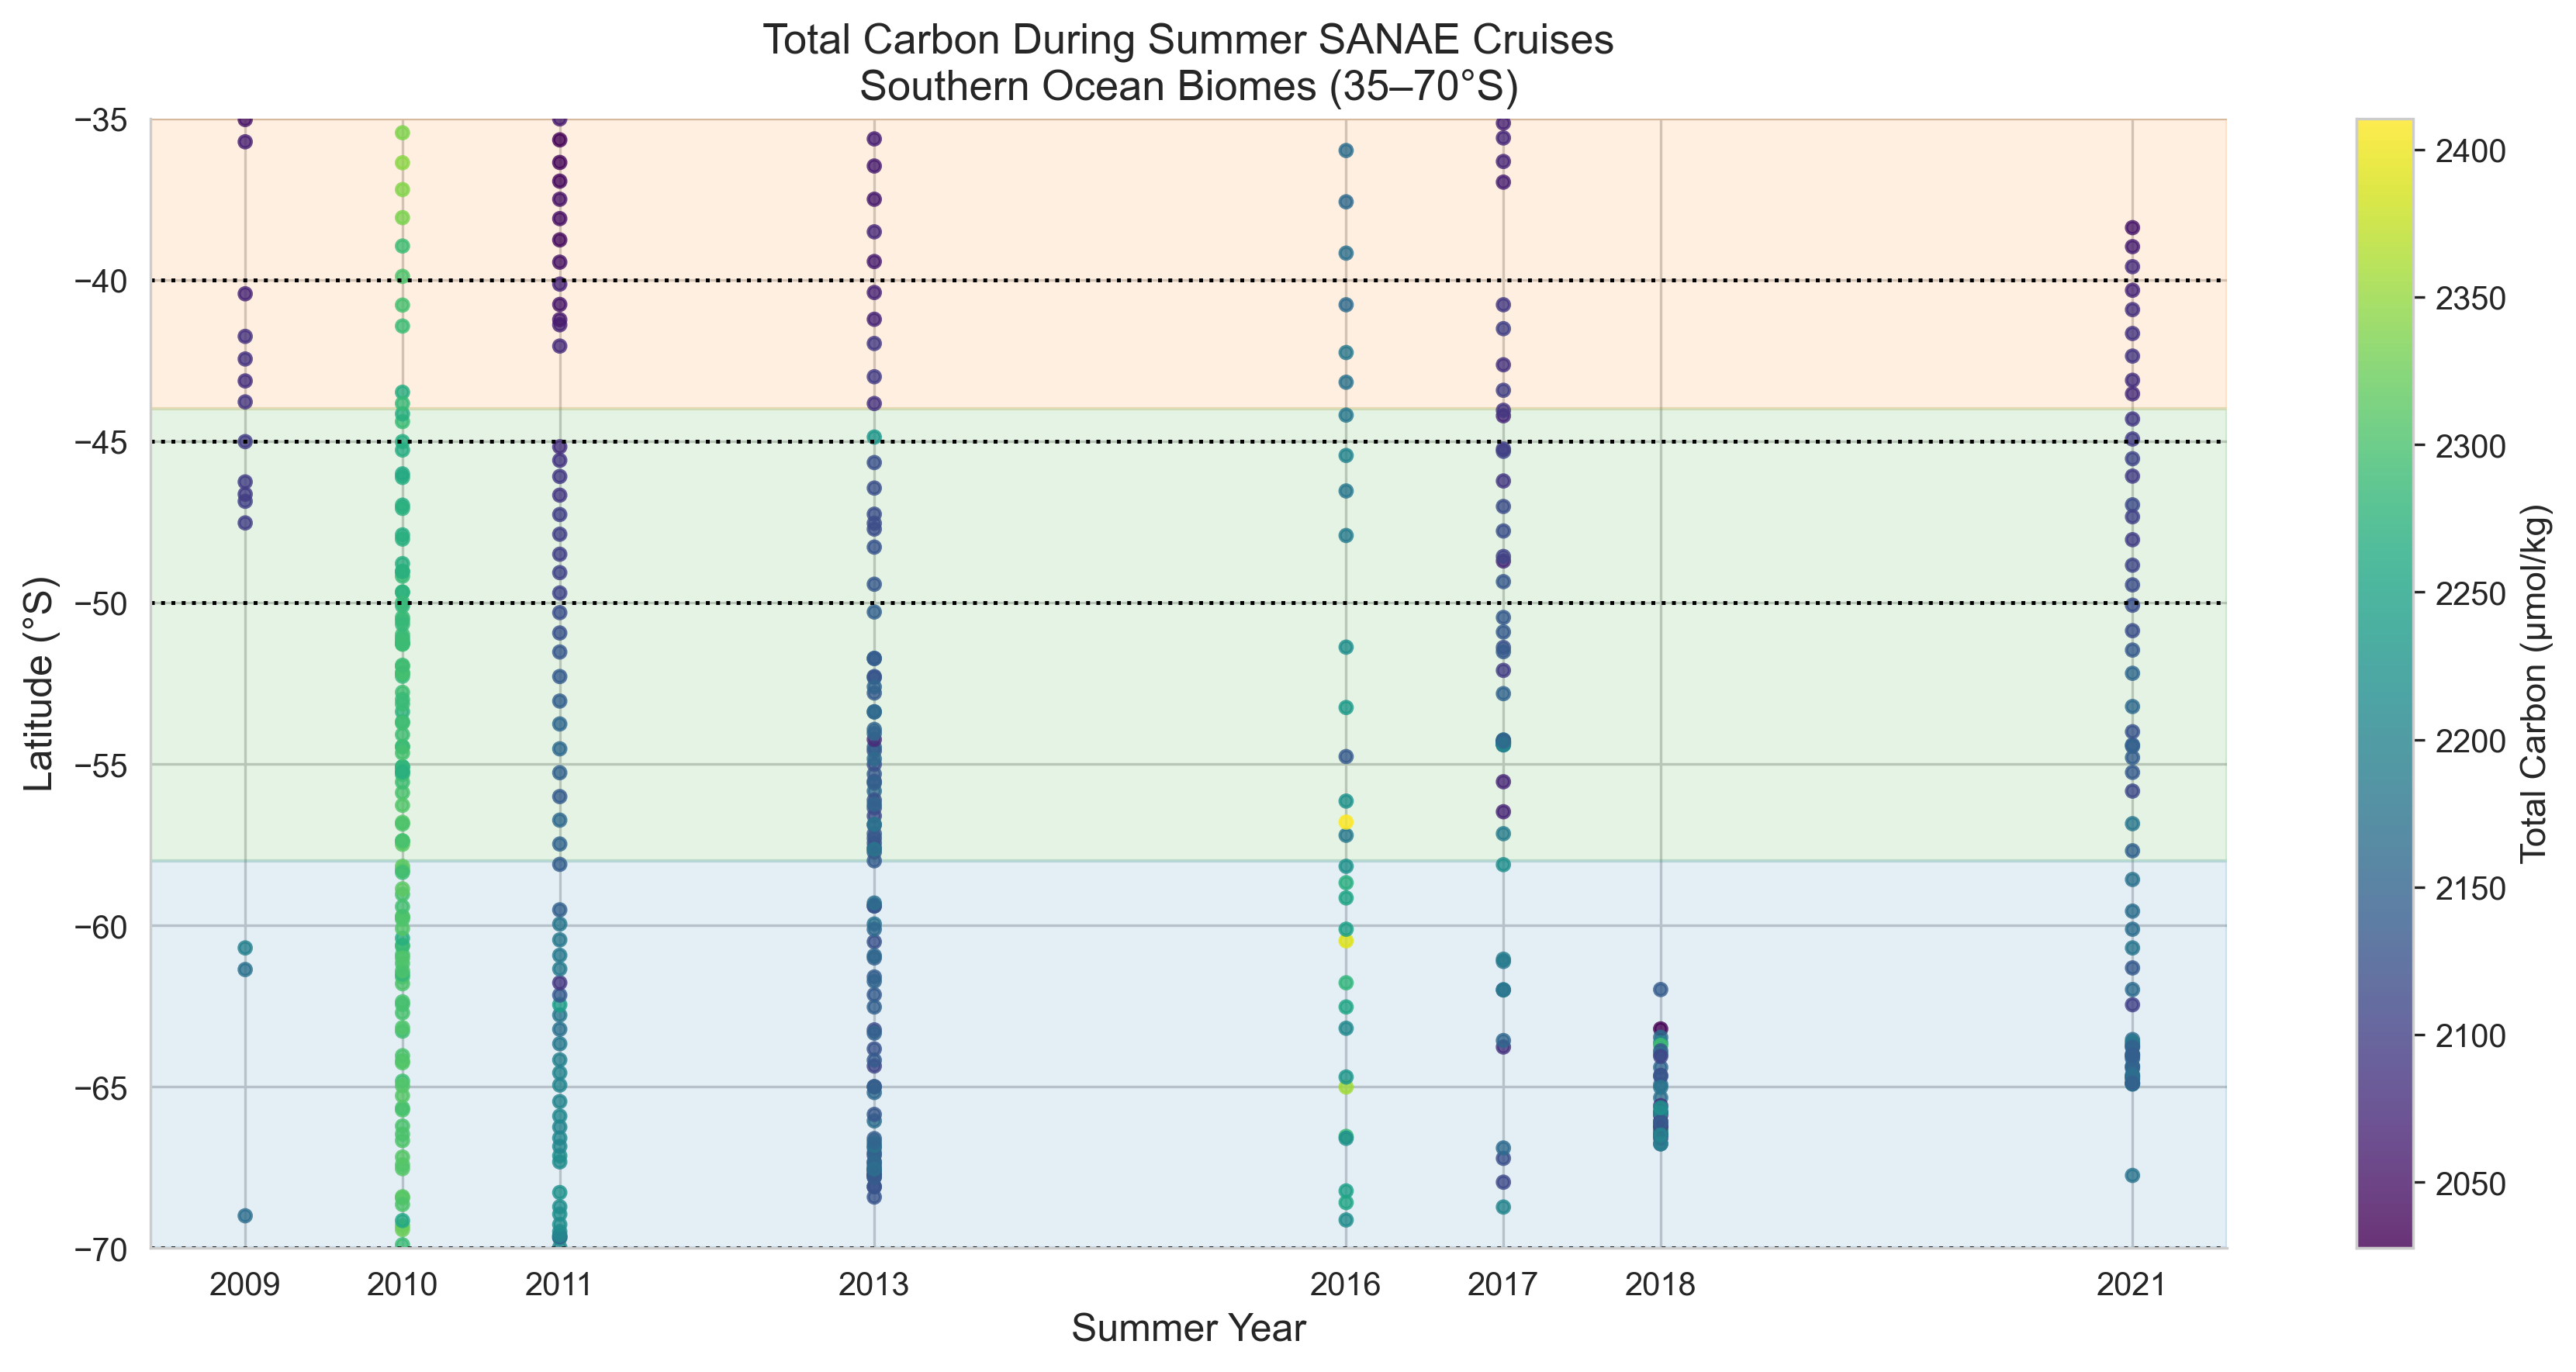

In [6]:
# ============================================================
# Define summers (Dec–Feb windows)
# ============================================================
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# ============================================================
# Assign summer year
# ============================================================
df['Summer_Year'] = np.nan

for year, (start, end) in summer_ranges.items():

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    mask = (df['Date'] >= start) & (df['Date'] <= end)

    df.loc[mask, 'Summer_Year'] = year

# -----------------------------
# Keep summer data only
# -----------------------------
df_summer = df.dropna(subset=['Summer_Year']).copy()

# ============================================================
# Restrict latitude range
# ============================================================
df_summer = df_summer[
    (df_summer['Lat'] >= -70) &
    (df_summer['Lat'] <= -35)
].copy()

# ============================================================
# Biome assignment function
# ============================================================
def assign_biome(lat):

    if -44 <= lat < -35:
        return "STSS (35–44°S)"

    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"

    elif -70 <= lat < -58:
        return "ICE (58–70°S)"

    else:
        return "Outside Defined Biome"

# -----------------------------
# Assign biome
# -----------------------------
df_summer['Biome'] = df_summer['Lat'].apply(assign_biome)

# -----------------------------
# Remove outside biome
# -----------------------------
df_summer = df_summer[
    df_summer['Biome'] != 'Outside Defined Biome'
]

# ============================================================
# Define biome colours
# ============================================================
biome_colors = {
    'STSS (35–44°S)': '#ff7f0e',
    'SPSS (44–58°S)': '#2ca02c',
    'ICE (58–70°S)': '#1f77b4'
}

# ============================================================
# Variables to plot
# ============================================================
variables = {
    'Salinity': 'Sea Surface Salinity (psu)',
    'Temperature': 'Sea Surface Temperature (°C)',
    'Total Alkalinity': 'Total Alkalinity (µmol/kg)',
    'Total Carbon': 'Total Carbon (µmol/kg)'
}

# ============================================================
# Create plots
# ============================================================
for variable, ylabel in variables.items():

    # -----------------------------------------
    # Drop NaNs for current variable
    # -----------------------------------------
    plot_df = df_summer.dropna(
        subset=[variable, 'Summer_Year', 'Lat']
    ).copy()

    # -----------------------------------------
    # Create figure
    # -----------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))

    # ========================================================
    # Background biome shading
    # ========================================================
    ax.axhspan(-44, -35,
               alpha=0.12,
               color='#ff7f0e')

    ax.axhspan(-58, -44,
               alpha=0.12,
               color='#2ca02c')

    ax.axhspan(-70, -58,
               alpha=0.12,
               color='#1f77b4')

    # ========================================================
    # Scatter plot
    # ========================================================
    scatter = ax.scatter(
        plot_df['Summer_Year'],
        plot_df['Lat'],
        c=plot_df[variable],
        cmap='viridis',
        s=14,
        alpha=0.8
    )

    # ========================================================
    # Front boundary lines
    # ========================================================
    ax.axhline(-40,
               linestyle=':',
               linewidth=1.2,
               color='black')

    ax.axhline(-45,
               linestyle=':',
               linewidth=1.2,
               color='black')

    ax.axhline(-50,
               linestyle=':',
               linewidth=1.2,
               color='black')

    ax.axhline(-70,
               linestyle=':',
               linewidth=1.2,
               color='black')

    # ========================================================
    # Labels and title
    # ========================================================
    ax.set_xlabel('Summer Year', fontsize=12)

    ax.set_ylabel('Latitude (°S)', fontsize=12)

    ax.set_title(
        f'{variable} During Summer SANAE Cruises\n'
        'Southern Ocean Biomes (35–70°S)',
        fontsize=13
    )

    # ========================================================
    # Latitude formatting
    # ========================================================
    ax.set_ylim(-70, -35)

    ax.set_yticks(np.arange(-70, -34, 5))

    # ========================================================
    # Year formatting
    # ========================================================
    ax.set_xticks(sorted(df_summer['Summer_Year'].dropna().unique()))

    # ========================================================
    # Colorbar
    # ========================================================
    cbar = plt.colorbar(scatter)

    cbar.set_label(ylabel, fontsize=11)

    # ========================================================
    # Improve style
    # ========================================================
    sns.despine()

    plt.tight_layout()

    # ========================================================
    # Save figure
    # ========================================================
    save_name = variable.replace(" ", "_")

    plt.savefig(
        f'{save_name}_vs_Years_Summer_Biomes.png',
        dpi=600,
        bbox_inches='tight'
    )

    plt.savefig(
        f'{save_name}_vs_Years_Summer_Biomes.pdf',
        bbox_inches='tight'
    )

    plt.show()